<h1 style="background-color:#4CD5FF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Diabetes Predictive Model
</h1>

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
About Dataset
</h2>

*This dataset is originally from the **National Institute of Diabetes and Digestive and Kidney Diseases**. The objective is to predict based on diagnostic measurements whether a patient has diabetes.*
*Several constraints were placed on the selection of these instances from a larger database. In particular, **all patients here are females at least 21 years old** of Pima Indian heritage.*

- **Pregnancies** - Number of times pregnant;
- **Glucose** - Plasma glucose concentration a 2 hours in an oral glucose tolerance test;
- **BloodPressure** - Diastolic blood pressure (mm Hg);
- **SkinThickness** - Triceps skin fold thickness (mm);
- **Insulin** - 2-Hour serum insulin (mu U/ml);
- **BMI** - Body mass index (weight in kg/(height in m)^2);
- **DiabetesPedigreeFunction** - Diabetes pedigree function;
- **Age** - Age (years);
- **Outcome** - Class variable (0 or 1);


<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Importing Libraries
</h2>

In [117]:
#!pip install lightgbm
import sqlite3
import os
import pandas as pd
import shap
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

# data partition
from sklearn.model_selection import train_test_split, GridSearchCV

from itertools import product
from scipy.stats import skewnorm

from datetime import datetime
from sklearn.svm import SVC
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression, lasso_path, LassoCV
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set()

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Importing DataFrame
</h2>

In [118]:
df_diabetes = pd.read_csv("C:/Users/mariana/Documents/Portefolio/diabetes.csv", delimiter=',', header=0, decimal='.', quotechar='"')

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Data Exploration 
</h2>

In [119]:
df_diabetes.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148,72,35,0,33.6,0.627,50,True
1,1,85,66,29,0,26.6,0.351,31,False
2,8,183,64,0,0,23.3,0.672,32,True
3,1,89,66,23,94,28.1,0.167,21,False
4,0,137,40,35,168,43.1,2.288,33,True


In [120]:
df_diabetes.tail()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
763,10,101,76,48,180,32.9,0.171,63,False
764,2,122,70,27,0,36.8,0.340,27,False
765,5,121,72,23,112,26.2,0.245,30,False
766,1,126,60,0,0,30.1,0.349,47,True
767,1,93,70,31,0,30.4,0.315,23,False


In [121]:
df_diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
bloodpressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skinthickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
bmi,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
diabetespedigreefunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


*By the count we can get an idea of 768 observations, however **glucose**, **bloodpressure**, **skinthickness**, **insulin** and **bmi** show a minimum of 0 which is medically unrealistic, therefore this might indicate some missing values encoded as 0.*

*The results also show that this sample of young adults with an **age** mean of 29 years has high values of **glucose** and **bmi**; **insulin** is highly right skewed as well as **diabetespedigreefunction** so we will have to look at the outliers of these variables carefully.*

In [122]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    bool   
dtypes: bool(1), float64(2), int64(6)
memory usage: 48.9 KB


*In terms of Nan values, there are none!*

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Data types, duplicate/missing/unique values, typecasting, feature stats
</h2>

In [123]:
df_diabetes.shape

(768, 9)

In [124]:
df_diabetes.dtypes


pregnancies                   int64
glucose                       int64
bloodpressure                 int64
skinthickness                 int64
insulin                       int64
bmi                         float64
diabetespedigreefunction    float64
age                           int64
outcome                        bool
dtype: object

In [125]:
df_diabetes.replace("", np.nan, inplace=True) #Replacing empty strings with NaN values
df_diabetes.isna().sum() #Checking the number of missing values in each feature of the dataset X

pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64

*To analyze better the presence of outliers, let's replace all zeros entries with Nan*

In [126]:
cols_with_zero = ['glucose', 'bloodpressure', 'skinthickness' , 'insulin', 'bmi']
df_diabetes[cols_with_zero] = df_diabetes[cols_with_zero].replace(0, np.nan)
df_diabetes.isna().sum()

pregnancies                   0
glucose                       5
bloodpressure                35
skinthickness               227
insulin                     374
bmi                          11
diabetespedigreefunction      0
age                           0
outcome                       0
dtype: int64

In [127]:
print("\nDuplicated values:", df_diabetes.duplicated().sum())


Duplicated values: 0


*There's no duplicated values on the datasets*

In [128]:
df_diabetes

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,True
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,False
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,True
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,True
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,False
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,False
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,False
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,True


In [129]:
for i in df_diabetes.columns:
    if df_diabetes[i].dtype != 'object':
        print(f"{i} unique values:{df_diabetes[i].unique()} |n")

pregnancies unique values:[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14] |n
glucose unique values:[148.  85. 183.  89. 137. 116.  78. 115. 197. 125. 110. 168. 139. 189.
 166. 100. 118. 107. 103. 126.  99. 196. 119. 143. 147.  97. 145. 117.
 109. 158.  88.  92. 122. 138. 102.  90. 111. 180. 133. 106. 171. 159.
 146.  71. 105. 101. 176. 150.  73. 187.  84.  44. 141. 114.  95. 129.
  79.  nan  62. 131. 112. 113.  74.  83. 136.  80. 123.  81. 134. 142.
 144.  93. 163. 151.  96. 155.  76. 160. 124. 162. 132. 120. 173. 170.
 128. 108. 154.  57. 156. 153. 188. 152. 104.  87.  75. 179. 130. 194.
 181. 135. 184. 140. 177. 164.  91. 165.  86. 193. 191. 161. 167.  77.
 182. 157. 178.  61.  98. 127.  82.  72. 172.  94. 175. 195.  68. 186.
 198. 121.  67. 174. 199.  56. 169. 149.  65. 190.] |n
bloodpressure unique values:[ 72.  66.  64.  40.  74.  50.  nan  70.  96.  92.  80.  60.  84.  30.
  88.  90.  94.  76.  82.  75.  58.  78.  68. 110.  56.  62.  85.  86.
  48.  44.  65. 108.  55. 122.  

*Everything seems to be fine with the data, there's no Nan's and all values are positive. Regarding the variable 'age', it will be kept as it is because i believe 'age' has a non-linear relationship with diabetes, therefore it will be better for analysis to compare this varible with other variables, as well as, if i change 'age' to represent the year of birth and then change it back to correlate all variables it will make the model more complex, which is not the objective.* 

*All variables are meric*

In [130]:
df_diabetes.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,True
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,False
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,True
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,True


*For future implementation of the predictive model, i made sure to convert the target from a boolean to a integer!*

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Data Undertanding
</h2>

#### Histograms

Text(0.5, 0.98, "Numeric Variables' Histograms")

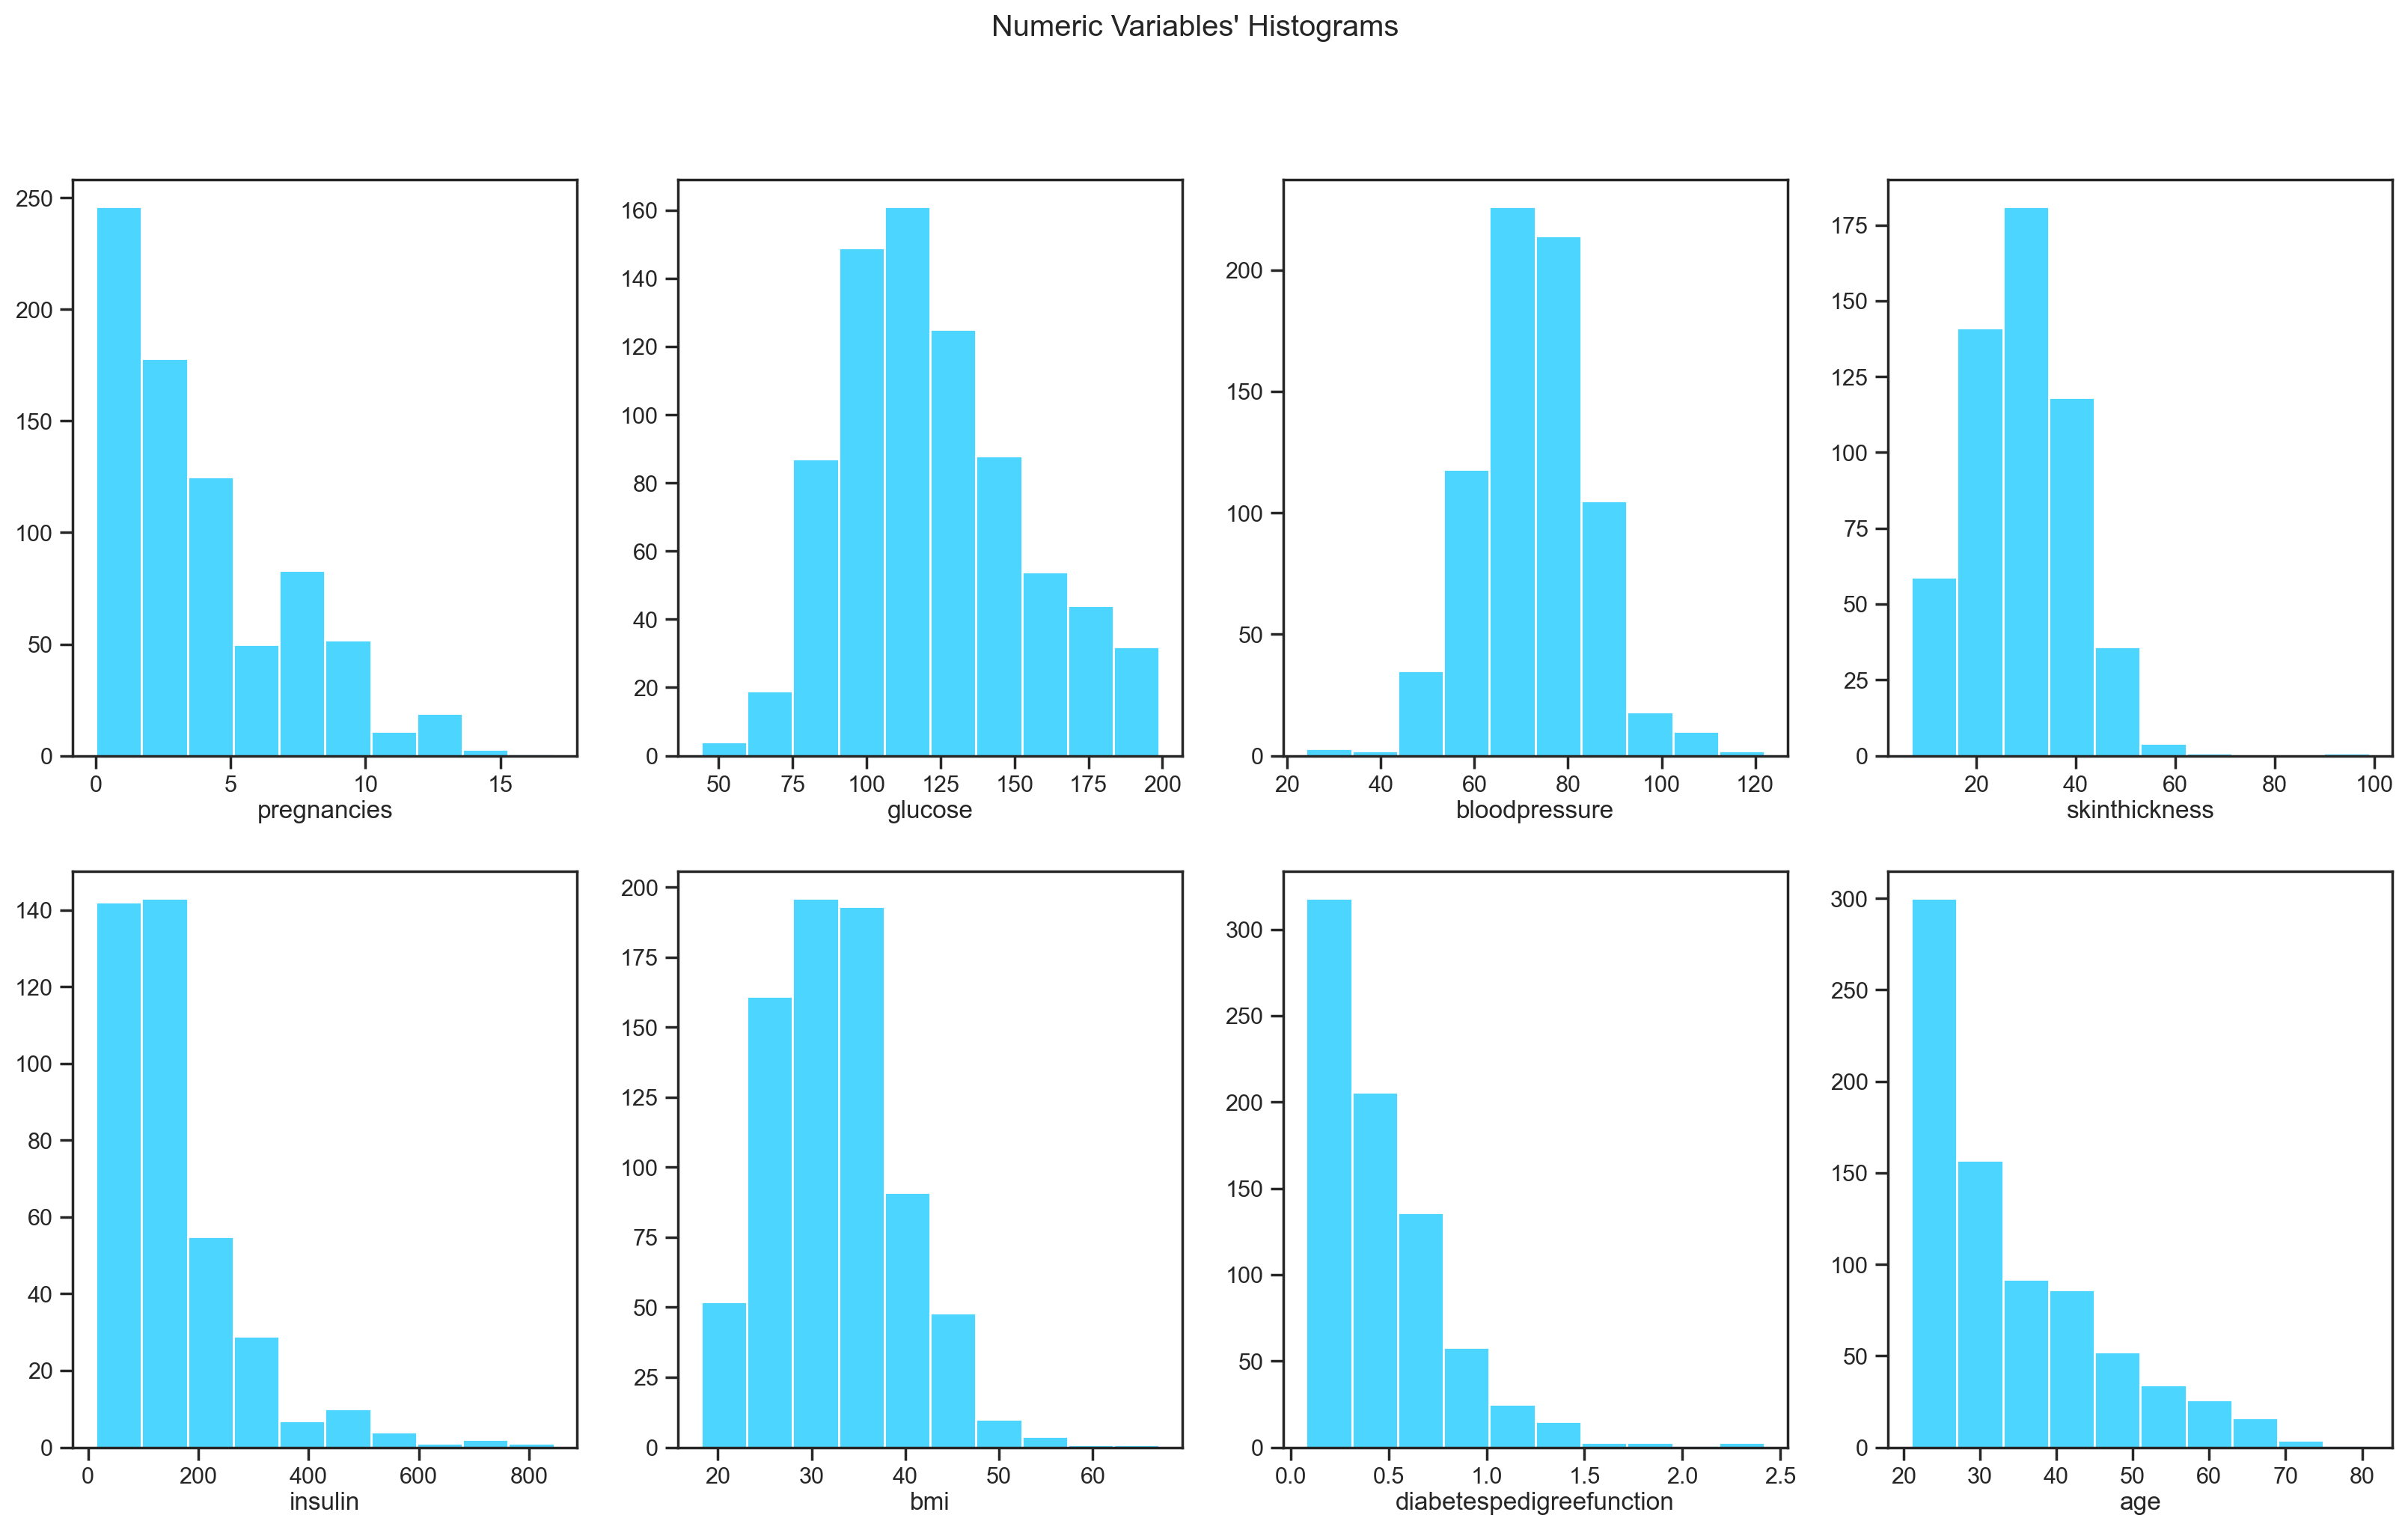

In [131]:
sp_rows = 2
sp_cols = 4

sns.set_style("ticks")
# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11))

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), df_diabetes): 
    ax.hist(df_diabetes[feat], color=('#4CD5FF'))
    ax.set_title(feat, y=-0.13)  
# Layout
plt.suptitle("Numeric Variables' Histograms")

#### BoxPlots

Text(0.5, 0.98, 'BoxPlots')

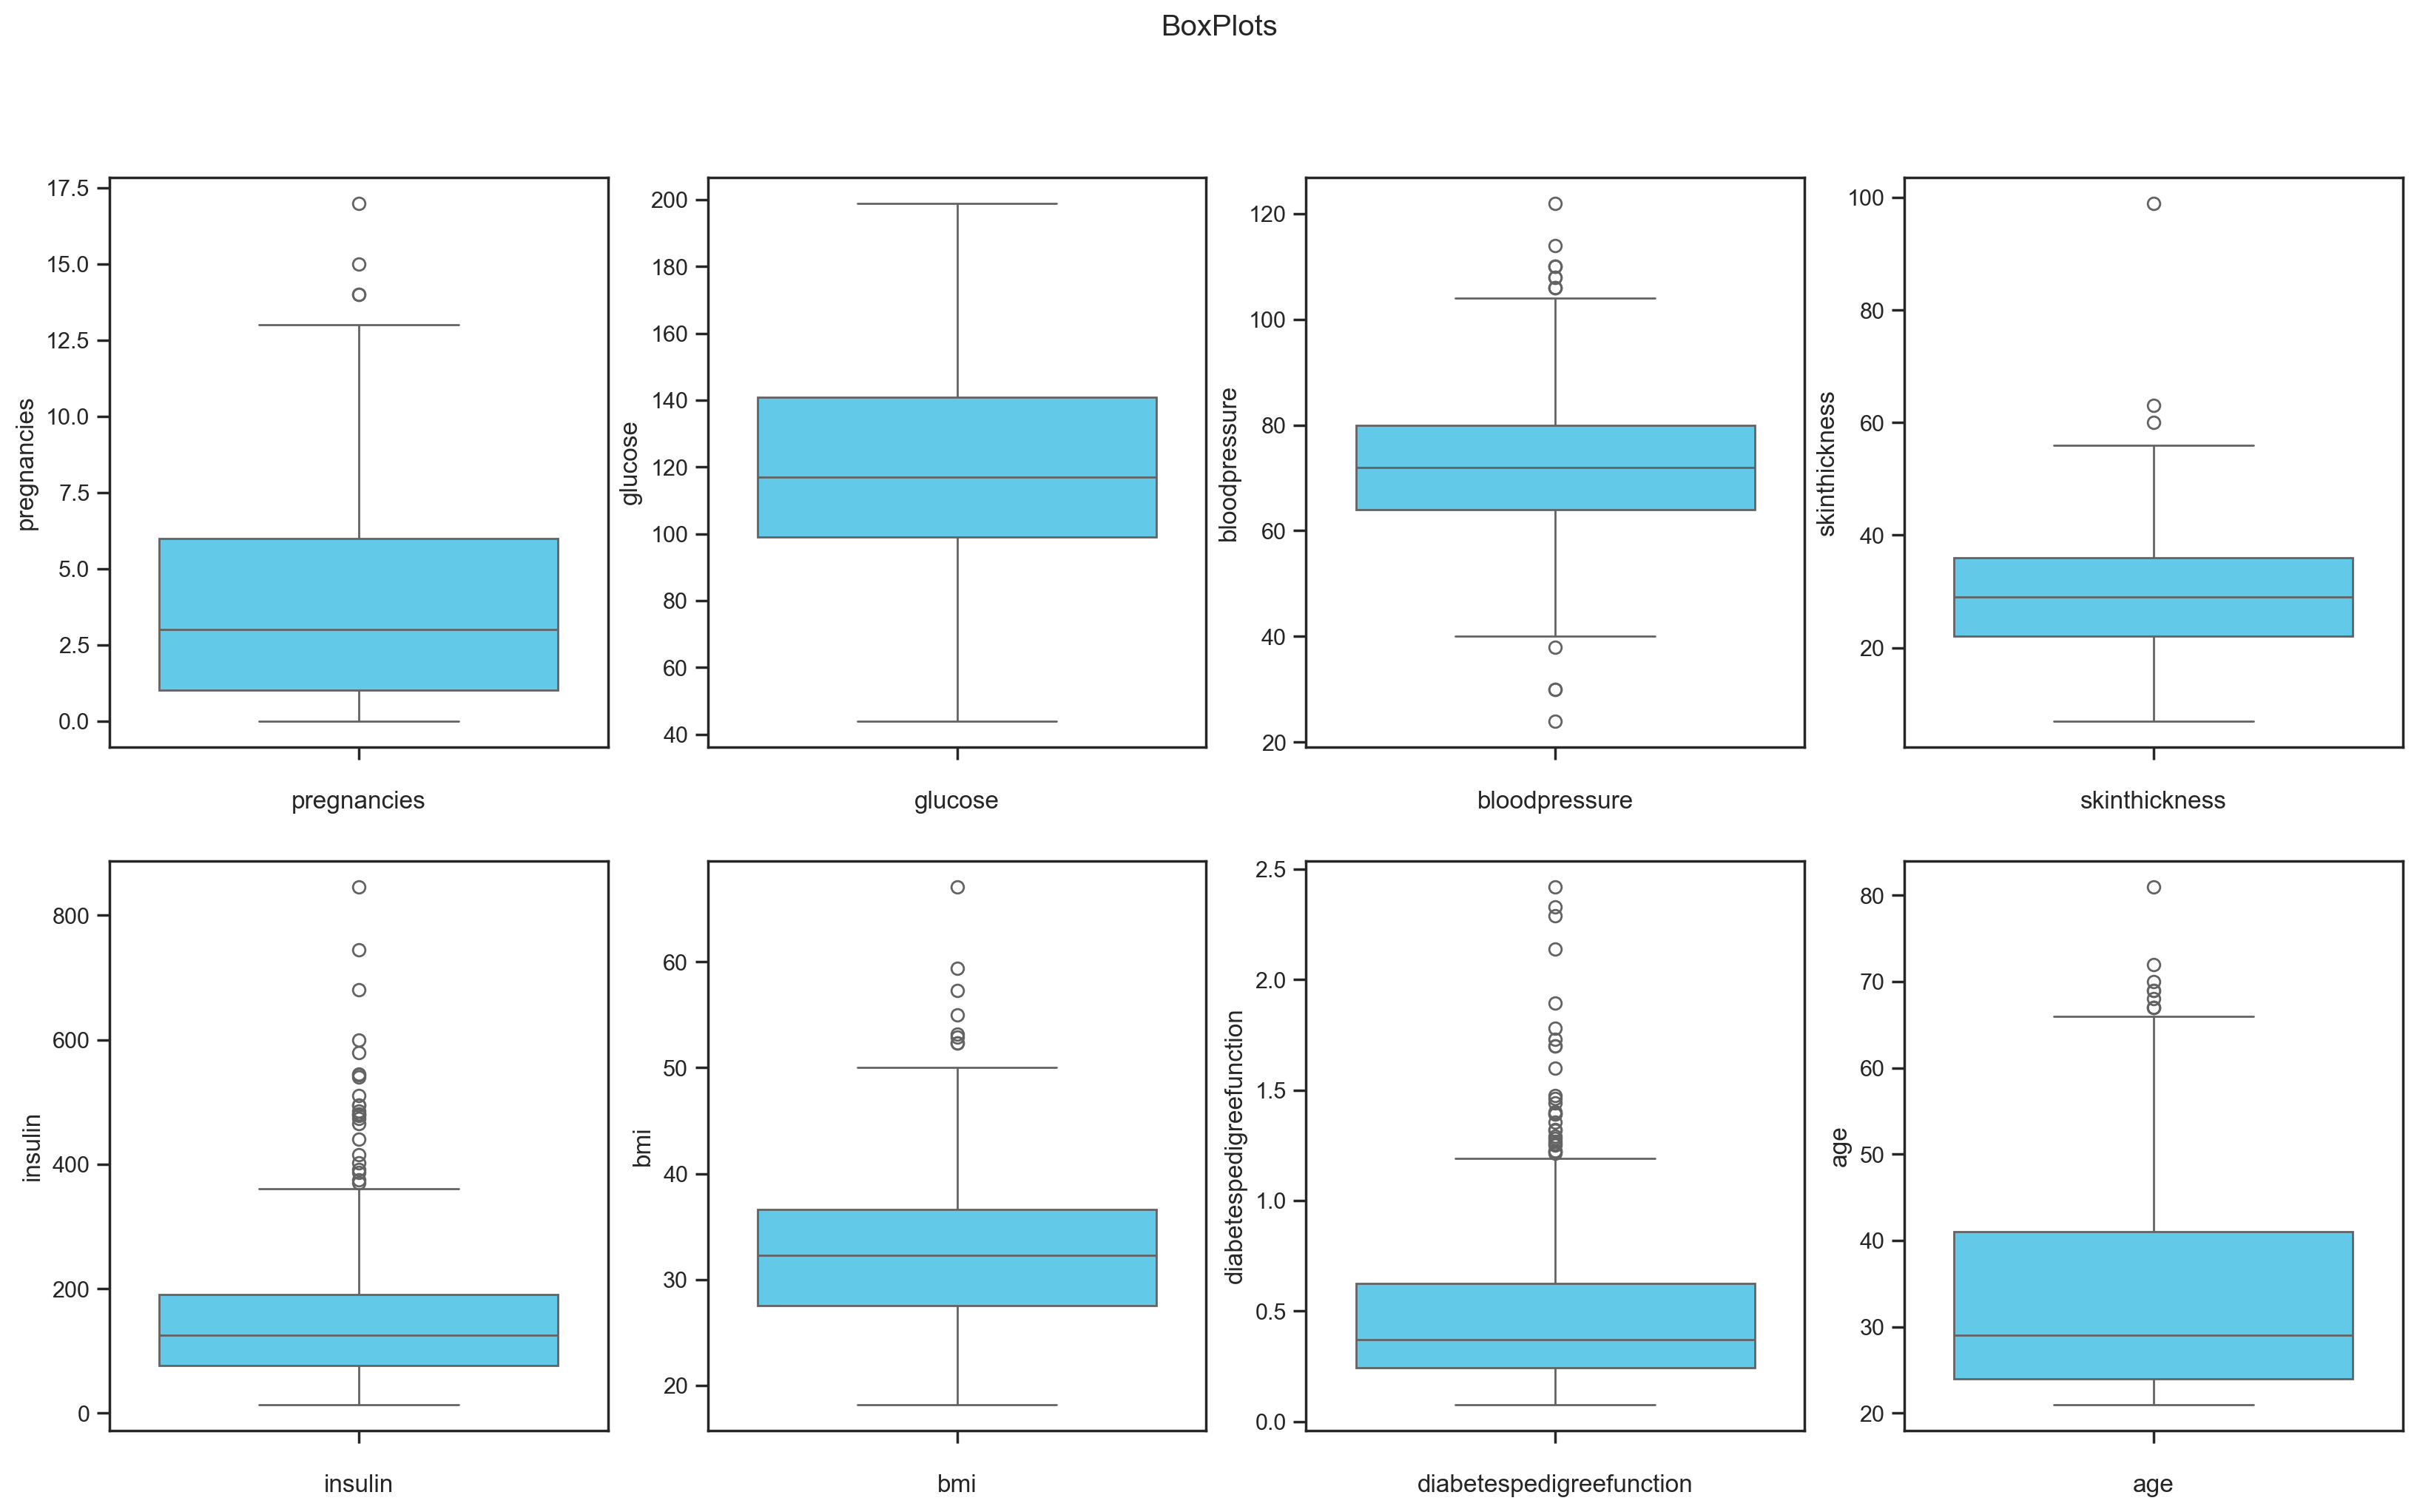

In [132]:
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11))

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), df_diabetes): 
    sns.boxplot(y=df_diabetes[feat],ax=ax, color=("#4CD5FF"))
    ax.set_title(feat, y=-0.13) 

plt.suptitle("BoxPlots")

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Correlation between the variables
</h2>

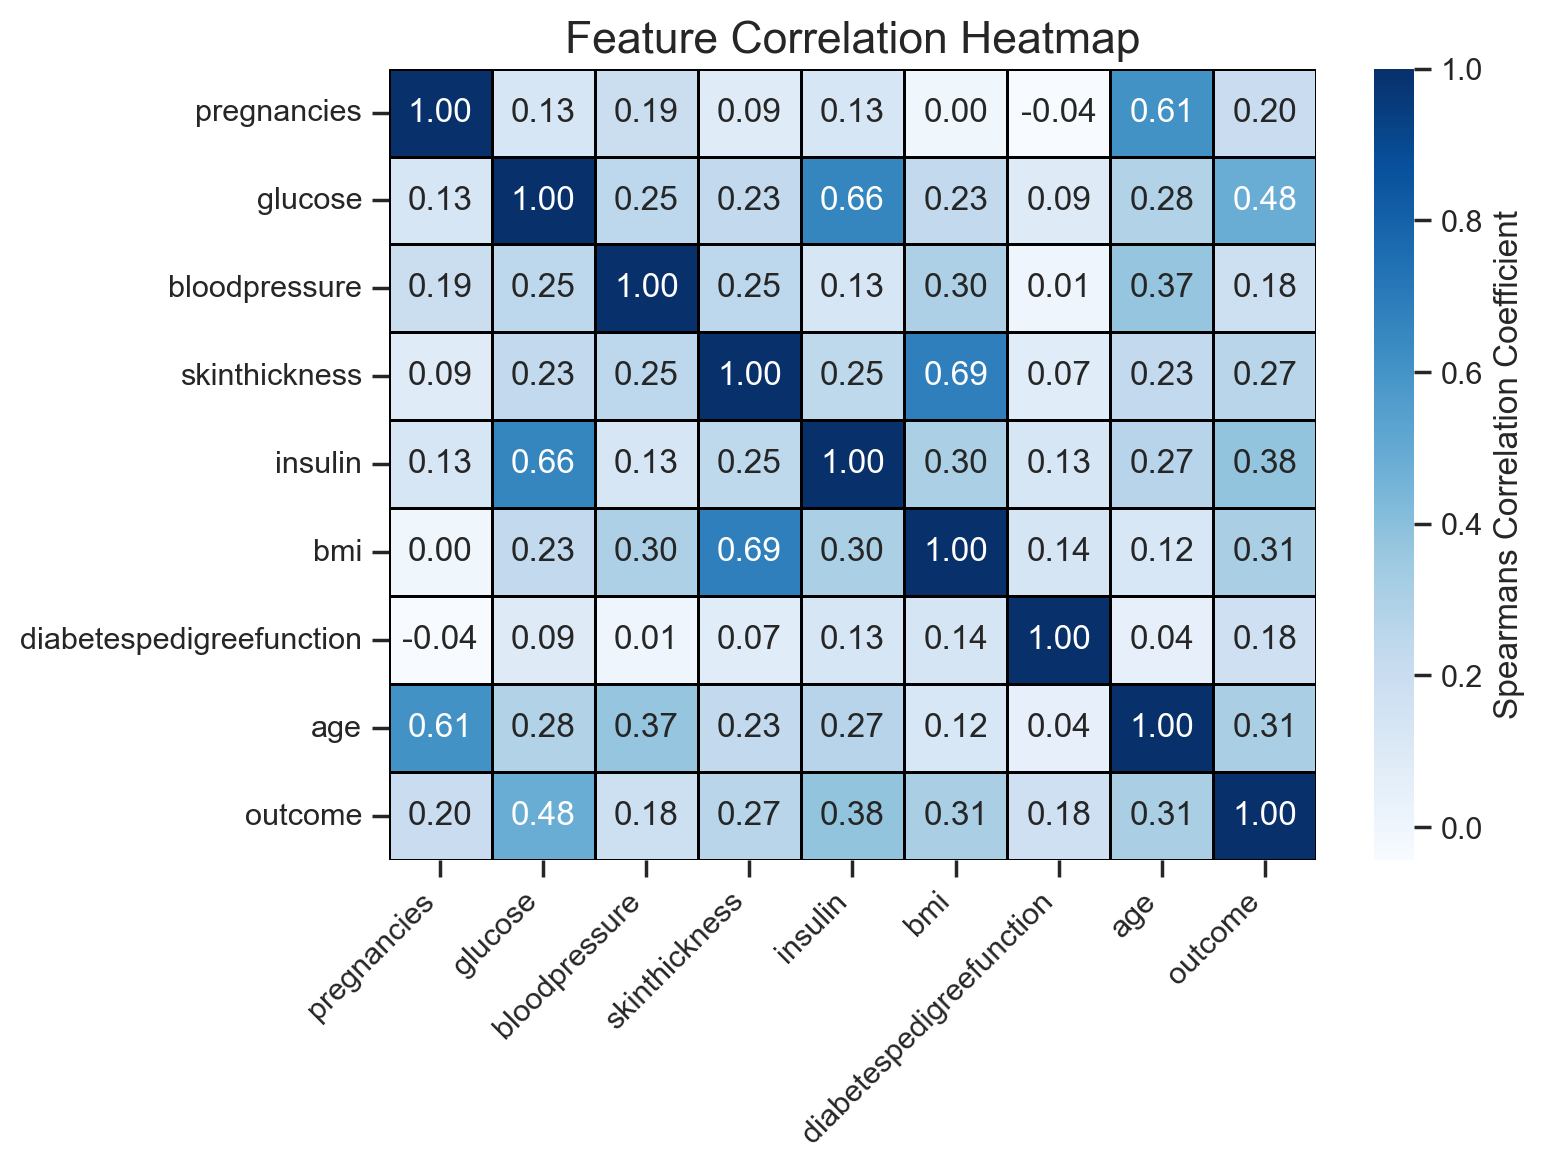

In [133]:
correlation_matrix_spearman = df_diabetes.corr(method='spearman')

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix_spearman,
    annot=True,     
    fmt=".2f",      
    cmap='Blues',
    linewidths=.5,
    linecolor='black',
    cbar_kws = {'label': 'Spearmans Correlation Coefficient'}
)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Splitting Data
</h2>

*Defining the **independent variables in X** and defining the **dependent variable in y** (the target)*

In [134]:
X = df_diabetes.drop('outcome', axis = 1)
y = df_diabetes['outcome']

*Using the method **train_test_split** to split the dataset into a train dataset (70%) amd the test dataset (30%)*

In [135]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, 
                                                 random_state = 0, 
                                                 stratify = y,
                                                 shuffle = True)

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Missing Values Treatment
</h2>

In [136]:
X_train.isna().sum()

pregnancies                   0
glucose                       3
bloodpressure                24
skinthickness               170
insulin                     282
bmi                           7
diabetespedigreefunction      0
age                           0
dtype: int64

*For the variables that have less than 5% of missing values, we will use the **median** to fill these missing values - **glucose**, **bloodpressure**, **bmi***

In [137]:
glucose_median = X_train['glucose'].median()
bp_median = X_train['bloodpressure'].median()
bmi_median = X_train['bmi'].median()

In [138]:
X_train['glucose'] = X_train['glucose'].fillna(glucose_median)
X_train['bloodpressure'] = X_train['bloodpressure'].fillna(bp_median)
X_train['bmi'] = X_train['bmi'].fillna(bmi_median)

In [139]:
X_val['glucose'] = X_val['glucose'].fillna(glucose_median)
X_val['bloodpressure'] = X_val['bloodpressure'].fillna(bp_median)
X_val['bmi'] = X_val['bmi'].fillna(bmi_median)

*The variable **skinthickness** has a considerable amount of missing values, therefore I'm going to use KNN to fill the missing values*

In [140]:
# Scalling and defining the imputer 
X_train_knn = X_train.copy()
X_val_knn = X_val.copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_knn)
X_val_scaled = scaler.transform(X_val_knn)

imputer = KNNImputer(n_neighbors=5)
X_train_imputed_scaled = imputer.fit_transform(X_train_scaled)
X_val_imputed_scaled = imputer.transform(X_val_scaled)

X_train_knn = scaler.inverse_transform(X_train_imputed_scaled)
X_val_knn = scaler.inverse_transform(X_val_imputed_scaled)

X_train_knn = pd.DataFrame(X_train_knn, columns=X_train.columns, index=X_train.index)
X_val_knn = pd.DataFrame(X_val_knn, columns=X_val.columns, index=X_val.index)

In [141]:
# Only applying it to the variable skinthickness
X_train["skinthickness"] = X_train_knn["skinthickness"]
X_val["skinthickness"] = X_val_knn["skinthickness"]

*The variable **insulin** has an extreme number of missing values, so I decided to create a new varible **missing_insulin** to understand if there is information that we can extract from this factor. Missing values values will also be filled with median.*

In [142]:
X_train["insulin_missing"] = X_train["insulin"].isna().astype(int)
median_insulin = X_train["insulin"].median()
X_train["insulin"] = X_train["insulin"].fillna(median_insulin)

In [143]:
# Since we are adding a new column to the dataset, we'll do the same to X_test
X_val["insulin_missing"] = X_val["insulin"].isna().astype(int)
X_val["insulin"] = X_val["insulin"].fillna(median_insulin)

In [144]:
X_train.isna().sum()

pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
insulin_missing             0
dtype: int64

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Outliers Analysis
</h2>

#### IQR

The **IQR (Interquartile Range)** is defined as:

$$IQR = Q3 - Q1$$

Where the outlier bounds are:

$$\text{Lower bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper bound} = Q3 + 1.5 \times IQR$$

In [145]:
def iqr_capping(df, col, cap=True):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if cap:
        df[col] = df[col].clip(lower, upper)
    return len(outliers), lower, upper

In [146]:
print("Before the Outlier Treatment")
for col in X_train.columns:
    n, _, _ = iqr_capping(X_train, col, cap=False)
    print(f"{col}: {n} outliers ({n/len(X_train):.2%})")

Before the Outlier Treatment
pregnancies: 3 outliers (0.56%)
glucose: 1 outliers (0.19%)
bloodpressure: 8 outliers (1.49%)
skinthickness: 6 outliers (1.12%)
insulin: 253 outliers (47.11%)
bmi: 8 outliers (1.49%)
diabetespedigreefunction: 23 outliers (4.28%)
age: 8 outliers (1.49%)
insulin_missing: 0 outliers (0.00%)


In [147]:
kept_outliers = ["pregnancies", "diabetespedigreefunction", "age"]
clip_bounds = {}  # store bounds here

for col in X_train.columns:
    if col not in kept_outliers:
        _, lower, upper = iqr_capping(X_train, col, cap=True)
        clip_bounds[col] = (lower, upper)

In [148]:
for col, (lower, upper) in clip_bounds.items():
    X_val[col] = X_val[col].clip(lower, upper)

In [149]:
print("After the Outlier Treatment")
for col in X_train.columns:
    n, _, _ = iqr_capping(X_train, col, cap=False)
    print(f"{col}: {n} outliers ({n/len(X_train):.2%})")

After the Outlier Treatment
pregnancies: 3 outliers (0.56%)
glucose: 0 outliers (0.00%)
bloodpressure: 0 outliers (0.00%)
skinthickness: 0 outliers (0.00%)
insulin: 0 outliers (0.00%)
bmi: 0 outliers (0.00%)
diabetespedigreefunction: 23 outliers (4.28%)
age: 8 outliers (1.49%)
insulin_missing: 0 outliers (0.00%)


To handle outliers, I used Interquartile Range (IQR) method. I calculated the lower and upper bounds from the training set and capped the all values outside of that interval. The features **pregnancies**, **age** and **diabetespedigreefunction** were purposely excluded from this procedure as their extreme values will be considered medically relevant rather than data errors. The computed bounds were then applied to the validation set using the same thresholds derived from training, ensuring no data leakage

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Scalling
</h2>

*To go forward with feature selection we will have to scale our variables to use some of the models.*

In [150]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train) # only using fit() on the train dataset because it's allowed to learn
X_val_scaled = scaler.transform(X_val)

In [151]:
# Converting back to a dataframe, with the data already scaled
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns = X_train.columns,
    index = X_train.index
)
X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns = X_val.columns,
    index = X_val.index
)

In [152]:
X_train_scaled

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,insulin_missing
34,1.4,0.153846,0.375,0.133333,0.0,-0.511494,0.385027,0.882353,0.0
221,-0.2,1.076923,1.125,0.000000,0.0,-0.051724,1.168449,2.117647,0.0
531,-0.6,-0.230769,0.250,1.150000,0.0,1.522989,0.850267,-0.352941,0.0
518,2.0,-1.025641,-0.750,0.500000,0.0,0.086207,-0.502674,0.647059,0.0
650,-0.4,-0.641026,-1.125,-0.366667,0.0,-0.787356,-0.358289,-0.411765,-1.0
...,...,...,...,...,...,...,...,...,...
628,0.4,0.307692,0.500,0.266667,0.0,0.293103,-0.598930,0.882353,0.0
456,-0.4,0.487179,-1.125,-0.150000,0.0,-0.614943,0.852941,1.882353,0.0
398,0.0,-0.871795,-0.125,-1.066667,0.0,-1.258621,0.056150,-0.294118,0.0
6,0.0,-0.974359,-1.375,0.216667,0.0,-0.120690,-0.320856,-0.235294,-1.0


StandardScaler was used temporarily to normalize the data prior to KNN imputation, as KNN is distance-based and requires features to be on a comparable scale. After imputation, the data was inverse-transformed back to its original scale. Now, RobustScaler is applied, chosen for its resilience to the skewness and outliers present in the dataset.
RobustScaler scales features using the median and interquartile range (IQR), since many variables seem to be highly right-skewed, with some variables appearing normal distributed - **glucose**, **bmi** and **bloodpreasure**. Also there are many outliers in the variable **insulin**, therefore  RobustScaler is more resilient in these situations.

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Feature Selection
</h2>

#### RFE

In [153]:
#no of features
nof_list=np.arange(1,len(X_train_scaled.columns)+1)            
high_score=0
#Variable to store the optimum features
nof=0           
train_score_list =[]
val_score_list = []

for n in range(len(nof_list)):
    model = LogisticRegression()
    
    rfe = RFE(estimator = model,n_features_to_select = nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train_scaled,y_train)
    X_val_rfe = rfe.transform(X_val_scaled)
    model.fit(X_train_rfe,y_train)
    
    #storing results on training data
    train_score = model.score(X_train_rfe,y_train)
    train_score_list.append(train_score)
    
    #storing results on validation data
    val_score = model.score(X_val_rfe,y_val)
    val_score_list.append(val_score)
    
    #check best score
    if(val_score >= high_score):
        high_score = val_score
        nof = nof_list[n]
print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

Optimum number of features: 4
Score with 4 features: 0.779221


RFE selects **4** features for its best score, and promising.

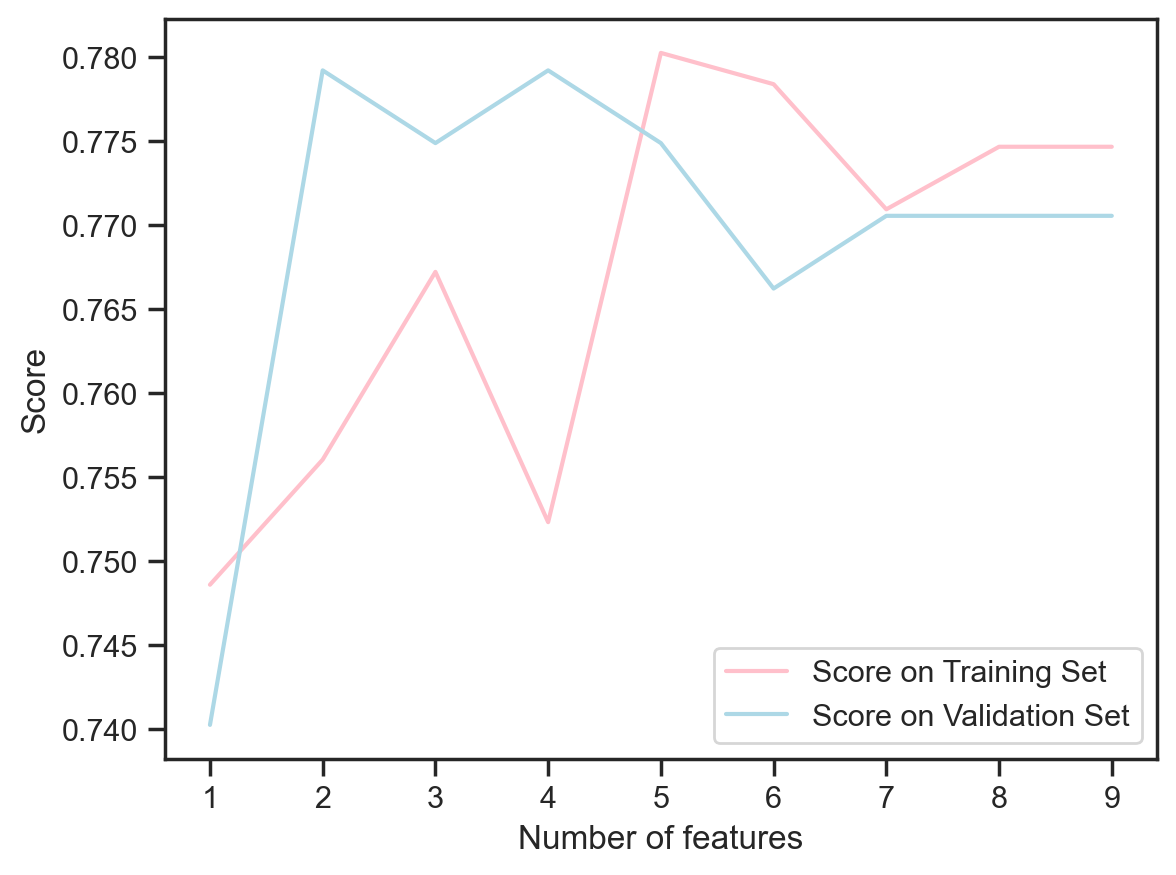

In [154]:
xs = range(1, len(train_score_list) + 1)
plt.plot(xs, train_score_list, label="Score on Training Set", color="pink")
plt.plot(xs, val_score_list, label="Score on Validation Set", color="lightblue")
plt.xlabel("Number of features")
plt.ylabel("Score")
plt.legend()

With this plot we can conclude that the training set has its best score with 5 features, and the validation set has the best score with 2 and 4 features.

In [155]:
rfe = RFE(LogisticRegression(), n_features_to_select=4)

rfe.fit(X_train_scaled, y_train)

selected_features = X_train_scaled.columns[rfe.support_]
print(selected_features)

Index(['pregnancies', 'glucose', 'bmi', 'insulin_missing'], dtype='object')


In [156]:
feature_ranking = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Ranking": rfe.ranking_
})

print(feature_ranking.sort_values("Ranking"))

                    Feature  Ranking
0               pregnancies        1
1                   glucose        1
5                       bmi        1
8           insulin_missing        1
6  diabetespedigreefunction        2
7                       age        3
3             skinthickness        4
2             bloodpressure        5
4                   insulin        6


For RFE, the features that allow for a stable score are **pregnancies**, **glucose**, **bmi** and **insulin_missing**.

#### Lasso

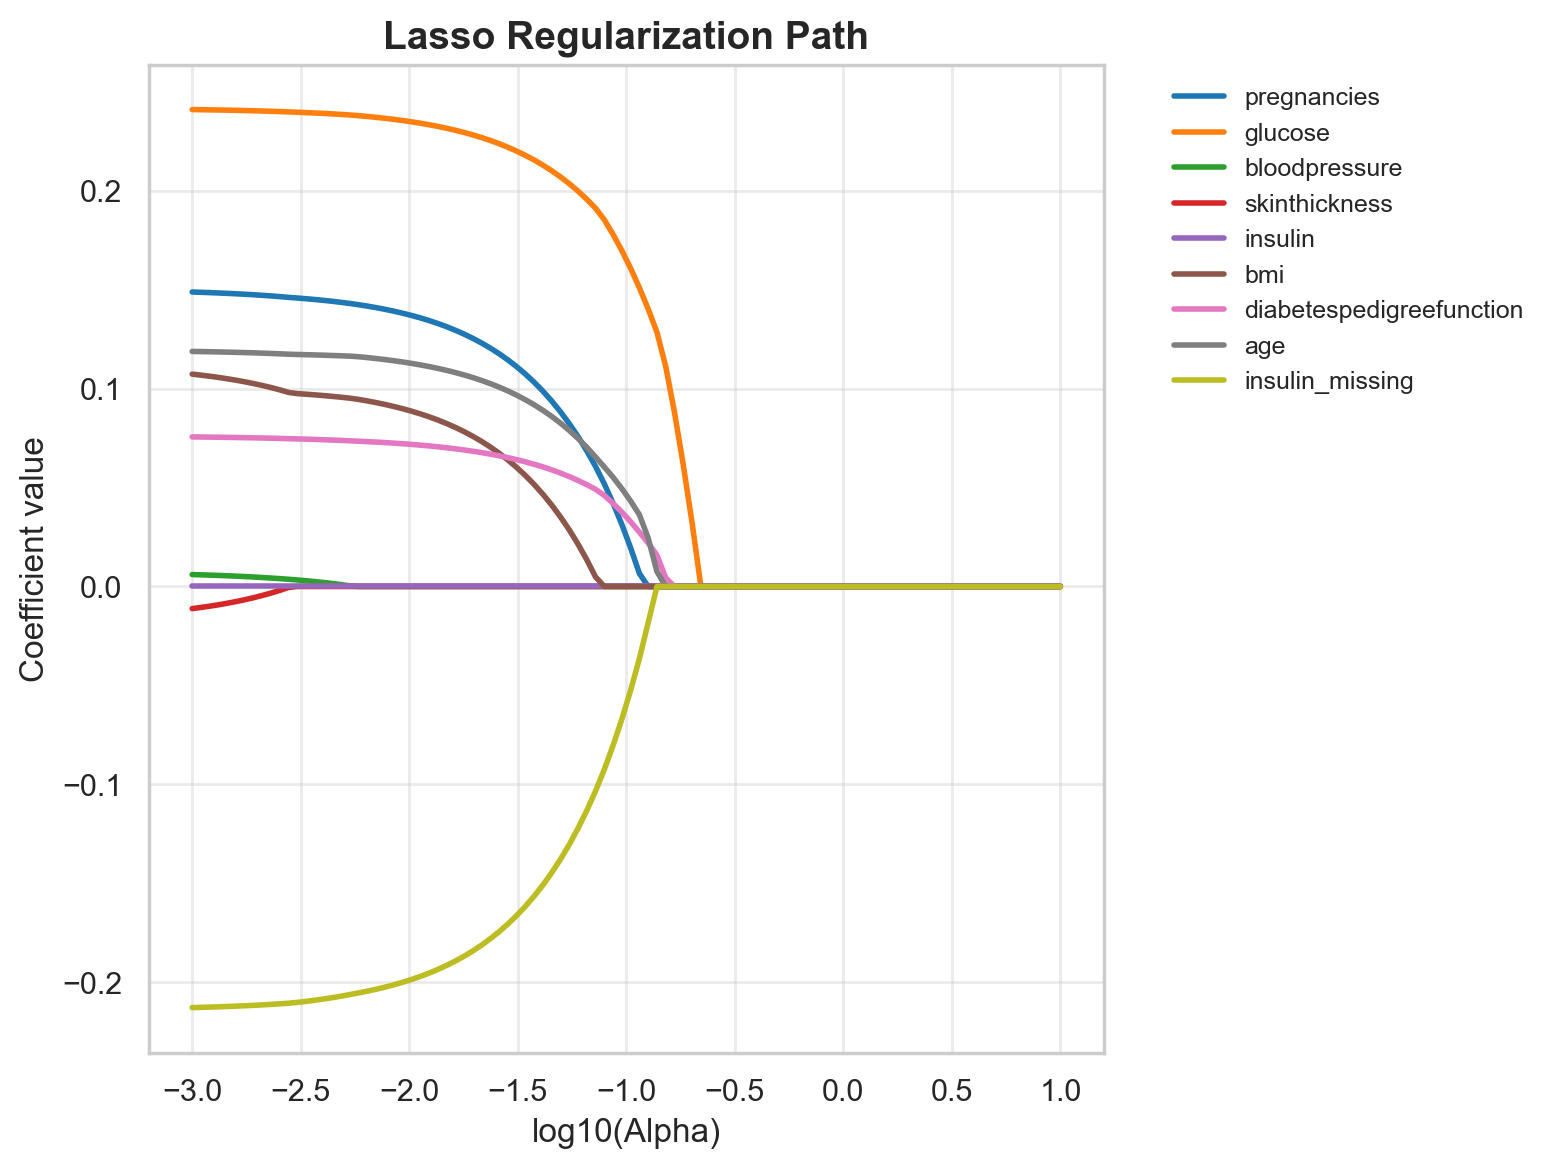

In [157]:
sns.set_theme(style="whitegrid")

alphas, coefs, _ = lasso_path(X_train_scaled, y_train, alphas=np.logspace(-3, 1, 100))

palette = sns.color_palette("tab10", n_colors=len(X_train_scaled.columns))

plt.figure(figsize=(8,6))
for i, (col, color) in enumerate(zip(X_train_scaled.columns, palette)):
    plt.plot(np.log10(alphas), coefs[i], label=col, color=color, linewidth=2)

plt.xlabel('log10(Alpha)', fontsize=12)
plt.ylabel('Coefficient value', fontsize=12)
plt.title('Lasso Regularization Path', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, frameon=False)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

By the plot done based on Lasso, the variables that are less helpfull for our model seems to be **skinthickness**, **insulin** and **bloodpreassure** as they shrink to zero earlier, suggesting a weaker contribution to the predictive model. The variable **glucose** is the most influential for the prediction, along with **pregnancies**, **age** and **bmi**.

In [158]:
reg = LassoCV()

In [159]:
reg.fit(X_train_scaled, y_train)

LassoCV()

In [160]:
coef = pd.Series(reg.coef_, index = X_train_scaled.columns)
coef

pregnancies                 0.086704
glucose                     0.233348
bloodpressure               0.000000
skinthickness               0.002240
insulin                     0.000000
bmi                         0.108112
diabetespedigreefunction    0.045743
age                         0.046869
insulin_missing             0.040516
dtype: float64

In [161]:
coef.sort_values()

bloodpressure               0.000000
insulin                     0.000000
skinthickness               0.002240
insulin_missing             0.040516
diabetespedigreefunction    0.045743
age                         0.046869
pregnancies                 0.086704
bmi                         0.108112
glucose                     0.233348
dtype: float64

In [162]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated " + str(sum(coef == 0)) + " variables")

Lasso picked 7 variables and eliminated 2 variables


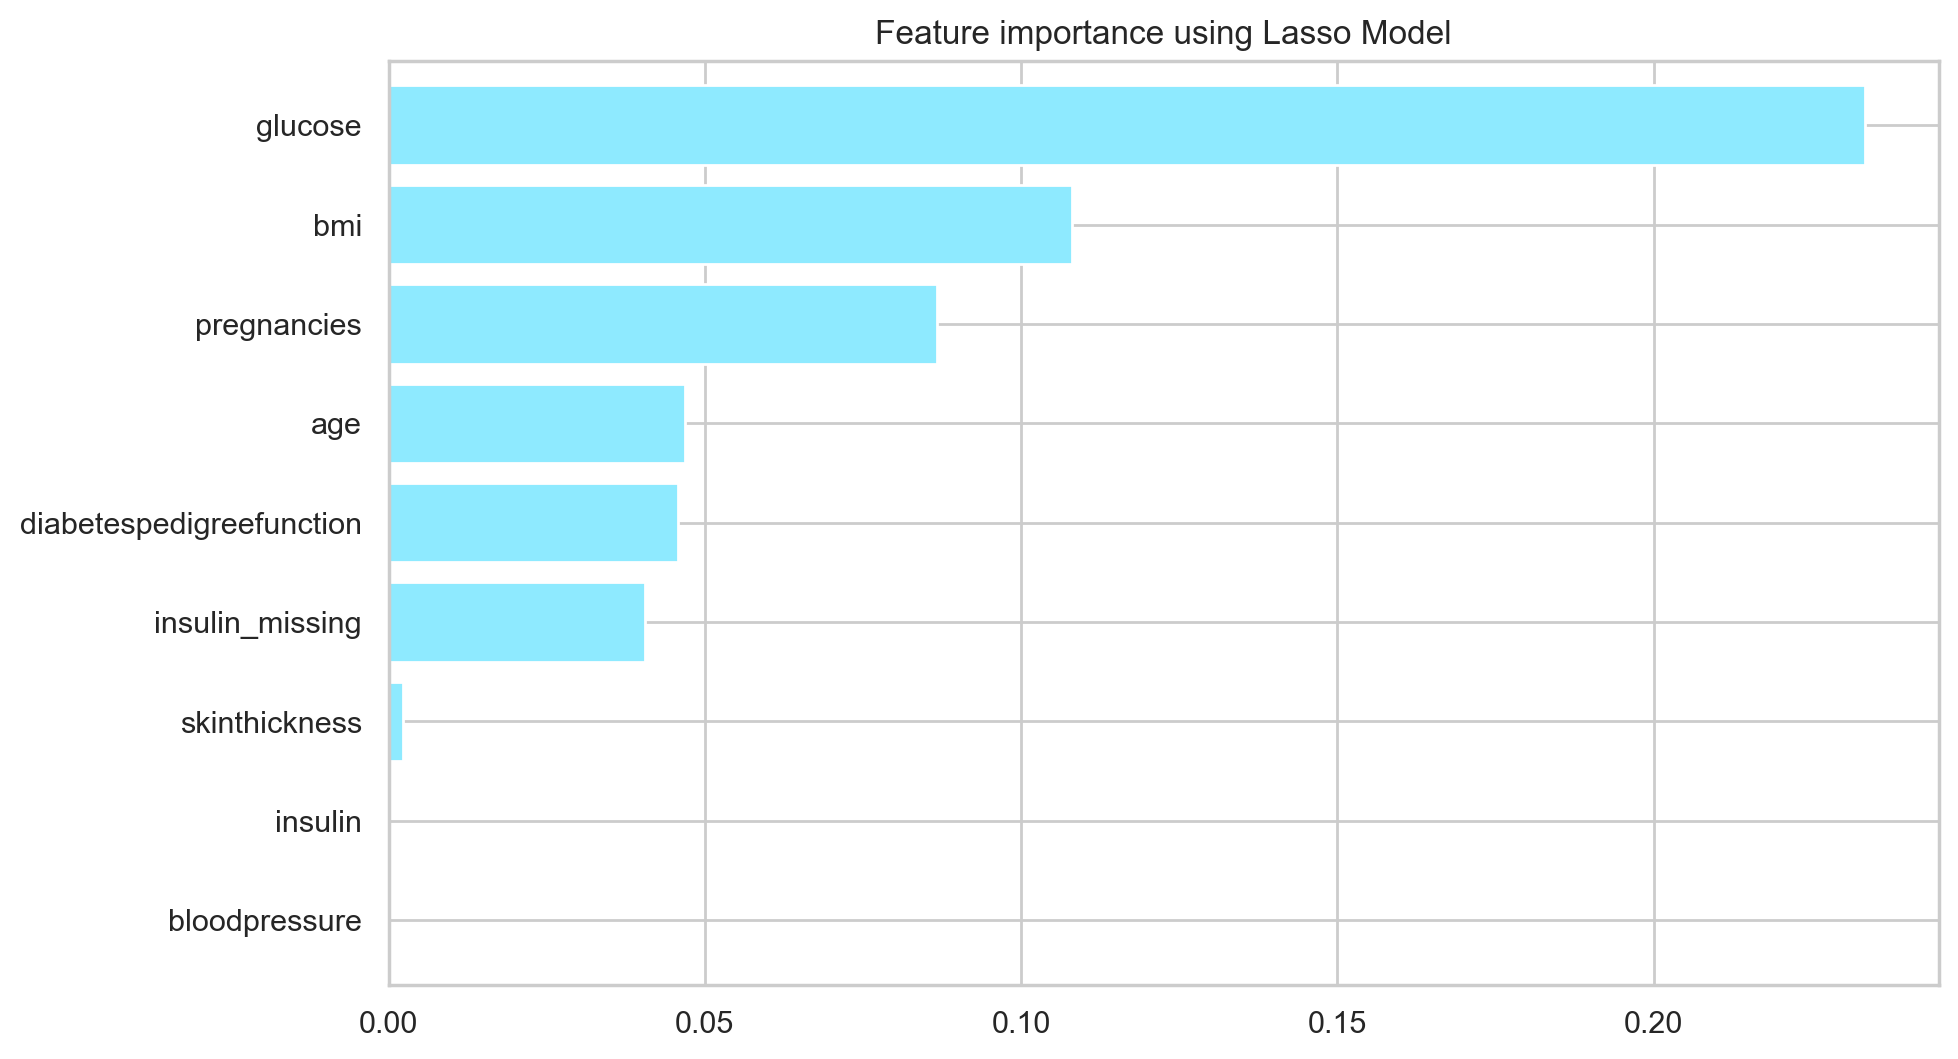

In [163]:
def plot_importance(coef,name):
    """
    Plot feature importance from model coefficients.
    Args:
        coef: Series of model coefficients.
        name: Name of the model (for title).
    """
    imp_coef = coef.sort_values()
    plt.figure(figsize=(10,6))
    imp_coef.plot(kind = "barh", color='#8EEAFF', width=0.8)
    plt.title("Feature importance using " + name + " Model")
    plt.show()

plot_importance(coef, "Lasso")

According to Lasso, we should remove **insulin** and **bloodpreasure** (coefficient == 0). Furthermore, **skinthickness** will not be considered for the predictive model as it will only be considered the variables with a coefficient bove 0,025. Therefore, the features moving forward are **glucose**, **bmi**, **pregnancies**, **age**, **diabetespedigreefunction** and **insulin_missing**.

#### Random Forest Classifier - Feature Importance 

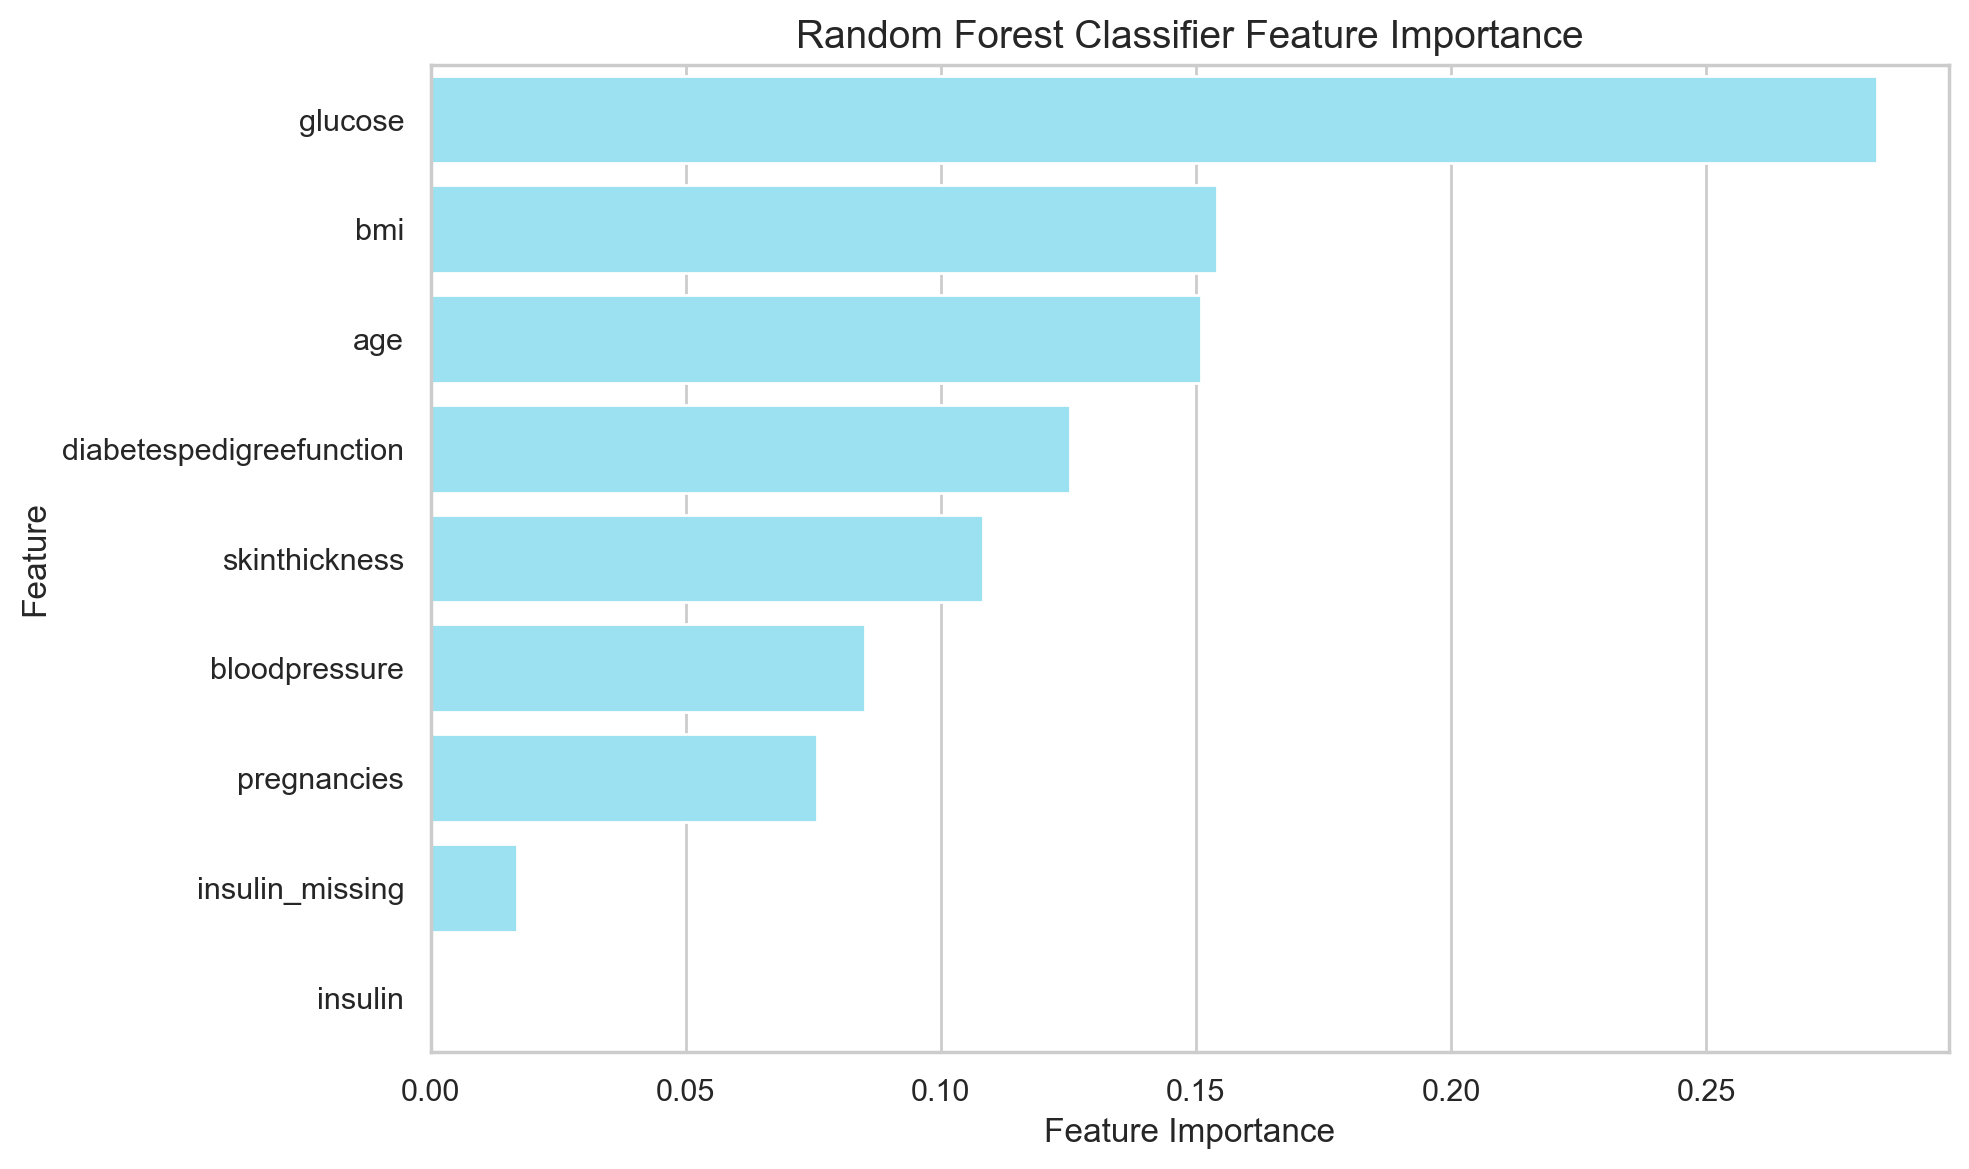

In [164]:
# Using a subset of data for Random Forest to speed up computation
sample_size = min(5000, len(X_train))   
X_all = X_train_scaled


X_sample = X_all.sample(n=sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Random Forest Classifier
rf = RandomForestClassifier(
    criterion='gini',   # correct criterion for classifier
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_sample, y_sample)

importances = rf.feature_importances_

# DataFrame with feature importances
imp_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': importances
})

# Sorting by importance
imp_df = imp_df.sort_values('Importance', ascending=False)

# Plotting top N features
top_n = 20
imp_top = imp_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=imp_top,
    y='Feature',
    x='Importance',
    color='#8EEAFF',
    width=0.8
)
plt.title('Random Forest Classifier Feature Importance', fontsize=14)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Let us assign a threshold of importance as 0.05 since we can not look at high marginal decrease or a percentage consideration, as no valid conclusion would be reached. Consequently, according to Random Forest Squared Error criteria, we discard **insulin** and **insulin_missing**.

#### SHAP

In [165]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [166]:
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_train)

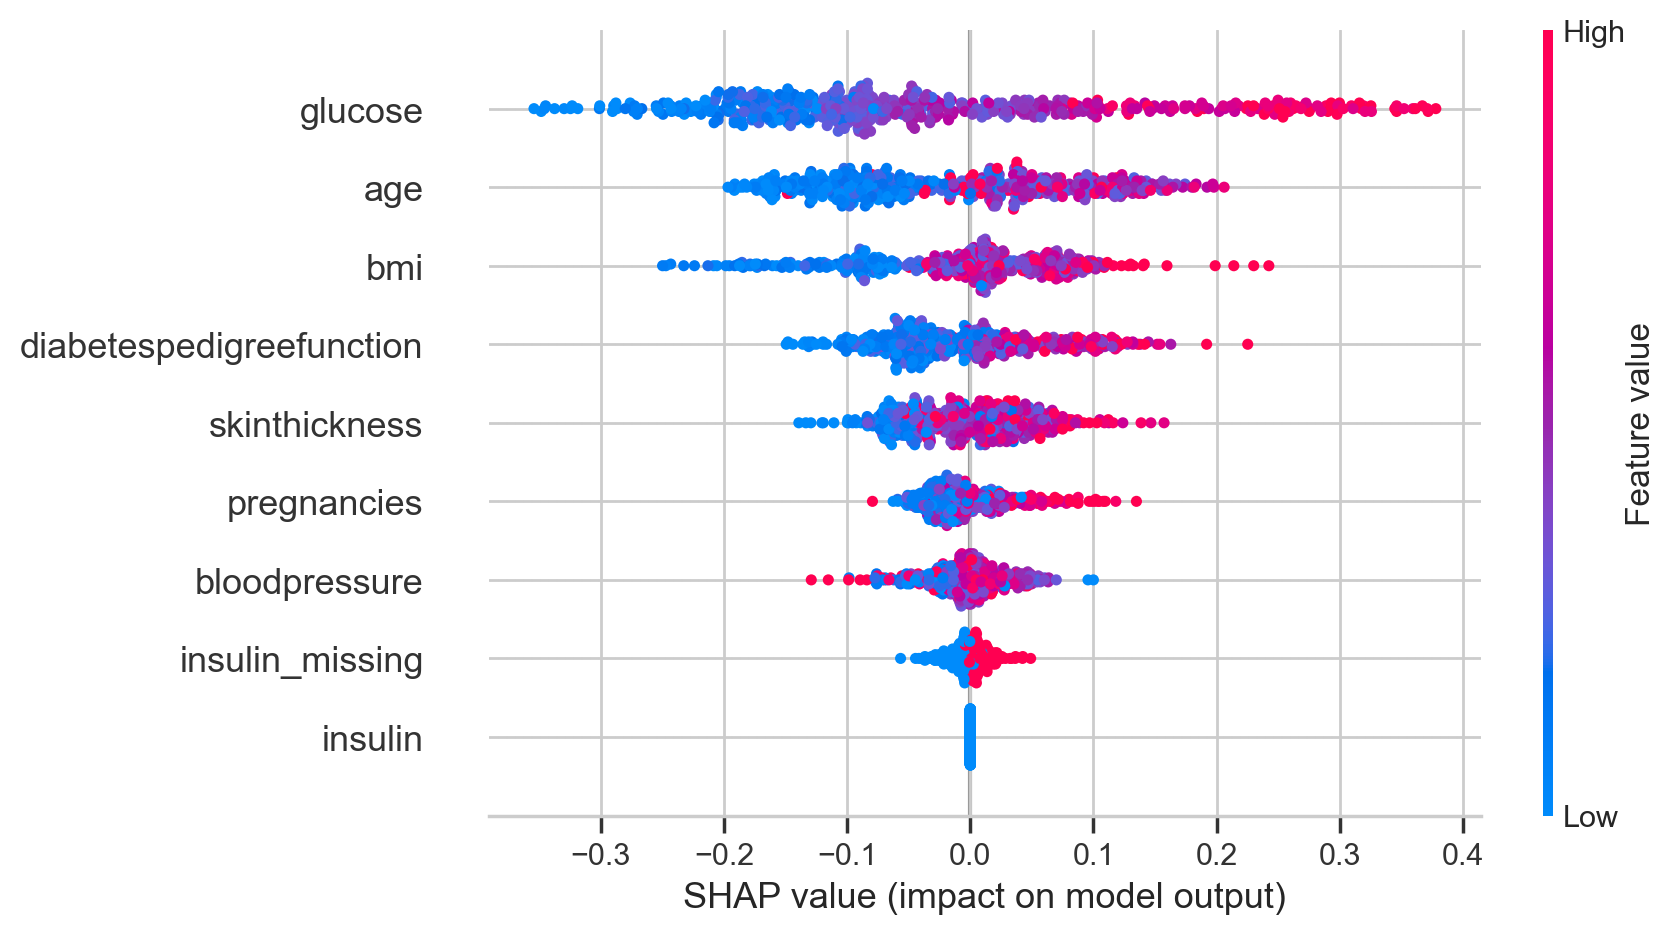

In [167]:
shap.plots.beeswarm(shap_values[:, :, 1])

The SHAP analysis was used to interpret the Random Forest model and quantify the contribution of each feature to the predictions, where blue represents a low feature value, pink represents a high feature value, also, positive values push towards a diabetes prediction and negative values pushs towards a non-diabetes prediction. 
The results indicate that **glucose** is the most influential predictor of diabetes, higher glucose levels increase the likelihood of a positive diabetes prediction. The variable **age** and **bmi** also exhibit strong positive effects for the model. Variables such as insulin and blood pressure have less impact, as their SHAP values remain close to zero.
These findings are consistent with the previous feature importance analyses, the Lasso and Random Forest models.

In [168]:
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_df.to_csv("feature_importance.csv", index=False)
print("Saved feature_importance.csv")

Saved feature_importance.csv


In [169]:
shap_class1 = shap_values[:, :, 1]
rows = []
for i, idx in enumerate(X_train.index):
    for j, feat in enumerate(X_train.columns):
        rows.append({
            "row_id": idx, "feature": feat,
            "feature_value": X_train.iloc[i, j],
            "shap_value": shap_class1.values[i, j],
            "outcome": y_train.loc[idx]
        })

shap_long_df = pd.DataFrame(rows)
shap_long_df.to_csv("shap_values.csv", index=False)
print("Saved shap_values.csv")

Saved shap_values.csv


<hr>

### Feature Selection Final Decision

| Predictor | RFE | LASSO | RANDOM FOREST | SHAP | FINAL DECISION | 
| --- | --- | --- |--- |---|---|
| glucose | Keep | Keep | Keep | Keep | Include in the model |
| age | Discard | Keep | Keep | Keep | Include in the model |
| bmi | Keep | Keep | Keep | Discard | Include in the model |
| diabetespedigreeefunction | Discard | Keep | Keep | Discard | Include in the model |
| skinthickness | Discard | Discard | Keep | Discard | Discard |
| pregnancies | Keep | Keep | Discard | Keep | Include in the model |
| blood_pressure | Discard | Discard | Keep | Discard | Discard |
| insulin_missing | Keep | Keep | Discrad | Discard | Include in the model |
| insulin | Discard | Discard | Discard | Discard | Discard |


maybe fazer um texto sobre **age**

<h2 style="background-color:#8EEAFF; color:white; padding:3px 6px; border-radius:4px; font-weight:bold;">
Predictive Models
</h2>

In [170]:
X_train_selected = X_train_scaled.drop(columns = ["skinthickness", "bloodpressure", "insulin"])
X_val_selected = X_val_scaled.drop(columns = ["skinthickness", "bloodpressure", "insulin"])

In [171]:
X_train_selected.columns

Index(['pregnancies', 'glucose', 'bmi', 'diabetespedigreefunction', 'age',
       'insulin_missing'],
      dtype='object')

In [172]:
X_val_selected.columns

Index(['pregnancies', 'glucose', 'bmi', 'diabetespedigreefunction', 'age',
       'insulin_missing'],
      dtype='object')

In [173]:
def evaluate_classification(model, x, y, split = ""):
    y_pred = model.predict(x) #model's prediction
    y_prob = model.predict_proba(x)[:, 1]
    return{
        "split": split,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1 Score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_prob)
    }

This function will be used for every model, in order to get a readible results.

#### Logistic Regression

In [174]:
log_model = LogisticRegression()

# Define the hyperparameter grid
param_grid = {
    'solver' :['sag', 'saga'],
    'penalty': ['l1','l2'],
    "C":np.logspace(-3,3,7)
}

grid_search = GridSearchCV(log_model, param_grid, cv=10, scoring='recall', n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train_selected, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print("Best Parameters:", best_params)


Best Parameters: {'C': np.float64(1.0), 'penalty': 'l1', 'solver': 'saga'}


In [175]:
final_model_log = LogisticRegression(solver = 'sag', penalty = 'l2', C=1.0)

In [176]:
final_model_log.fit(X_train_selected, y_train)

LogisticRegression(solver='sag')

In [177]:
train_results = evaluate_classification(final_model_log, X_train_selected, y_train, "train")
val_results = evaluate_classification(final_model_log, X_val_selected, y_val, "val")

metrics_df = pd.DataFrame([
    evaluate_classification(final_model_log, X_train_selected, y_train, "train"),
    evaluate_classification(final_model_log, X_val_selected, y_val, "val")
])

display(metrics_df)

,split,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,train,0.778399,0.736111,0.566845,0.640483,0.838335
1,val,0.766234,0.721311,0.543210,0.619718,0.866749


#### Random Forest Classifier 

In [178]:
rc_model = RandomForestClassifier(random_state=42)
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_rc = GridSearchCV(rc_model, param_grid, cv=10, scoring='recall', n_jobs=-1)

grid_search_rc.fit(X_train_selected, y_train)

best_params = grid_search_rc.best_params_
print("Best Parameters:", best_params)


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [179]:
final_rc_model = RandomForestClassifier(
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

final_rc_model.fit(X_train_selected, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, random_state=42)

In [180]:
metrics_df_rc = pd.DataFrame([
    evaluate_classification(final_rc_model, X_train_selected, y_train, "train"),
    evaluate_classification(final_rc_model, X_val_selected, y_val, "val")
])

display(metrics_df_rc)

,split,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,train,0.852886,0.745455,0.877005,0.805897,0.931979
1,val,0.761905,0.651163,0.691358,0.670659,0.849383


#### XGBoost

In [181]:
xgb_model = XGBClassifier(random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=10, scoring='recall', n_jobs=-1)

grid_search_xgb.fit(X_train_selected, y_train)

best_params_xgb = grid_search_xgb.best_params_

print("Best Parameters for XGBoost:", best_params_xgb)

Best Parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}


In [182]:
final_xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42
)

final_xgb_model.fit(X_train_selected, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [183]:
metrics_df_xgb = pd.DataFrame([
    evaluate_classification(final_xgb_model, X_train_selected, y_train, "train"),
    evaluate_classification(final_xgb_model, X_val_selected, y_val, "val")
])

display(metrics_df_xgb)

,split,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,train,0.813780,0.745763,0.705882,0.725275,0.899389
1,val,0.770563,0.700000,0.604938,0.649007,0.839835


#### LightGBM

In [184]:
gbm_model = LGBMClassifier(random_state=42)
param_grid_gbm = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_gbm = GridSearchCV(gbm_model, param_grid_gbm, cv=10, scoring='recall', n_jobs=-1)

grid_search_gbm.fit(X_train_selected, y_train)

best_params_gbm = grid_search_gbm.best_params_
print("Best Parameters for GBM:", best_params_gbm)

[LightGBM] [Info] Number of positive: 187, number of negative: 350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 461
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348231 -> initscore=-0.626825
[LightGBM] [Info] Start training from score -0.626825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [185]:
final_gbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42
)

final_gbm_model.fit(X_train_selected, y_train)

[LightGBM] [Info] Number of positive: 187, number of negative: 350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 461
[LightGBM] [Info] Number of data points in the train set: 537, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348231 -> initscore=-0.626825
[LightGBM] [Info] Start training from score -0.626825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(learning_rate=0.01, max_depth=3, n_estimators=200,
               random_state=42)

In [186]:
metrics_df_gbm = pd.DataFrame([
    evaluate_classification(final_gbm_model, X_train_selected, y_train, "train"),   
    evaluate_classification(final_gbm_model, X_val_selected, y_val, "val")
])
display(metrics_df_gbm)

,split,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,train,0.810056,0.740113,0.700535,0.719780,0.896677
1,val,0.774892,0.710145,0.604938,0.653333,0.839424


#### Support Vector Classification

In [187]:
svc_model = SVC(probability=True, random_state=42)
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_search_svc = GridSearchCV(svc_model, param_grid_svc, cv=10, scoring='recall', n_jobs=-1)

grid_search_svc.fit(X_train_selected, y_train)

best_params_svc = grid_search_svc.best_params_
print("Best Parameters for SVC:", best_params_svc)

Best Parameters for SVC: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [188]:
final_svc_model = SVC(
    C=10,
    kernel='linear',
    gamma='scale',
    probability=True,
    random_state=42
)

final_svc_model.fit(X_train_selected, y_train)

SVC(C=10, kernel='linear', probability=True, random_state=42)

In [189]:
metrics_df_svc = pd.DataFrame([
    evaluate_classification(final_svc_model, X_train_selected, y_train, "train"),
    evaluate_classification(final_svc_model, X_val_selected, y_val, "val")
])  

display(metrics_df_svc)

,split,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,train,0.774674,0.729167,0.561497,0.634441,0.837899
1,val,0.766234,0.721311,0.543210,0.619718,0.868313


In [190]:
metrics_df["Model"] = "Logistic Regression"
metrics_df_rc["Model"] = "Random Forest"
metrics_df_xgb["Model"] = "XGBoost"
metrics_df_gbm["Model"] = "LightGBM"
metrics_df_svc["Model"] = "SVM"

all_metrics_df = pd.concat([metrics_df, metrics_df_rc, metrics_df_xgb, metrics_df_gbm, metrics_df_svc])
all_metrics_df.to_csv("model_metrics.csv", index=False)
print("Saved model_metrics.csv")

Saved model_metrics.csv


In [191]:
val_predictions_df = X_val.copy()
val_predictions_df["actual_outcome"] = y_val.values

models_dict = {
    "Logistic_Regression": final_model_log,
    "Random_Forest": final_rc_model,
    "XGBoost": final_xgb_model,
    "LightGBM": final_gbm_model,
    "SVM": final_svc_model,
}

for name, model in models_dict.items():
    val_predictions_df[f"prob_{name}"] = model.predict_proba(X_val_selected)[:, 1]
    val_predictions_df[f"pred_{name}"] = model.predict(X_val_selected)

val_predictions_df.to_csv("validation_predictions.csv", index=False)
print("Saved validation_predictions.csv")

Saved validation_predictions.csv


##### Model's Visualization

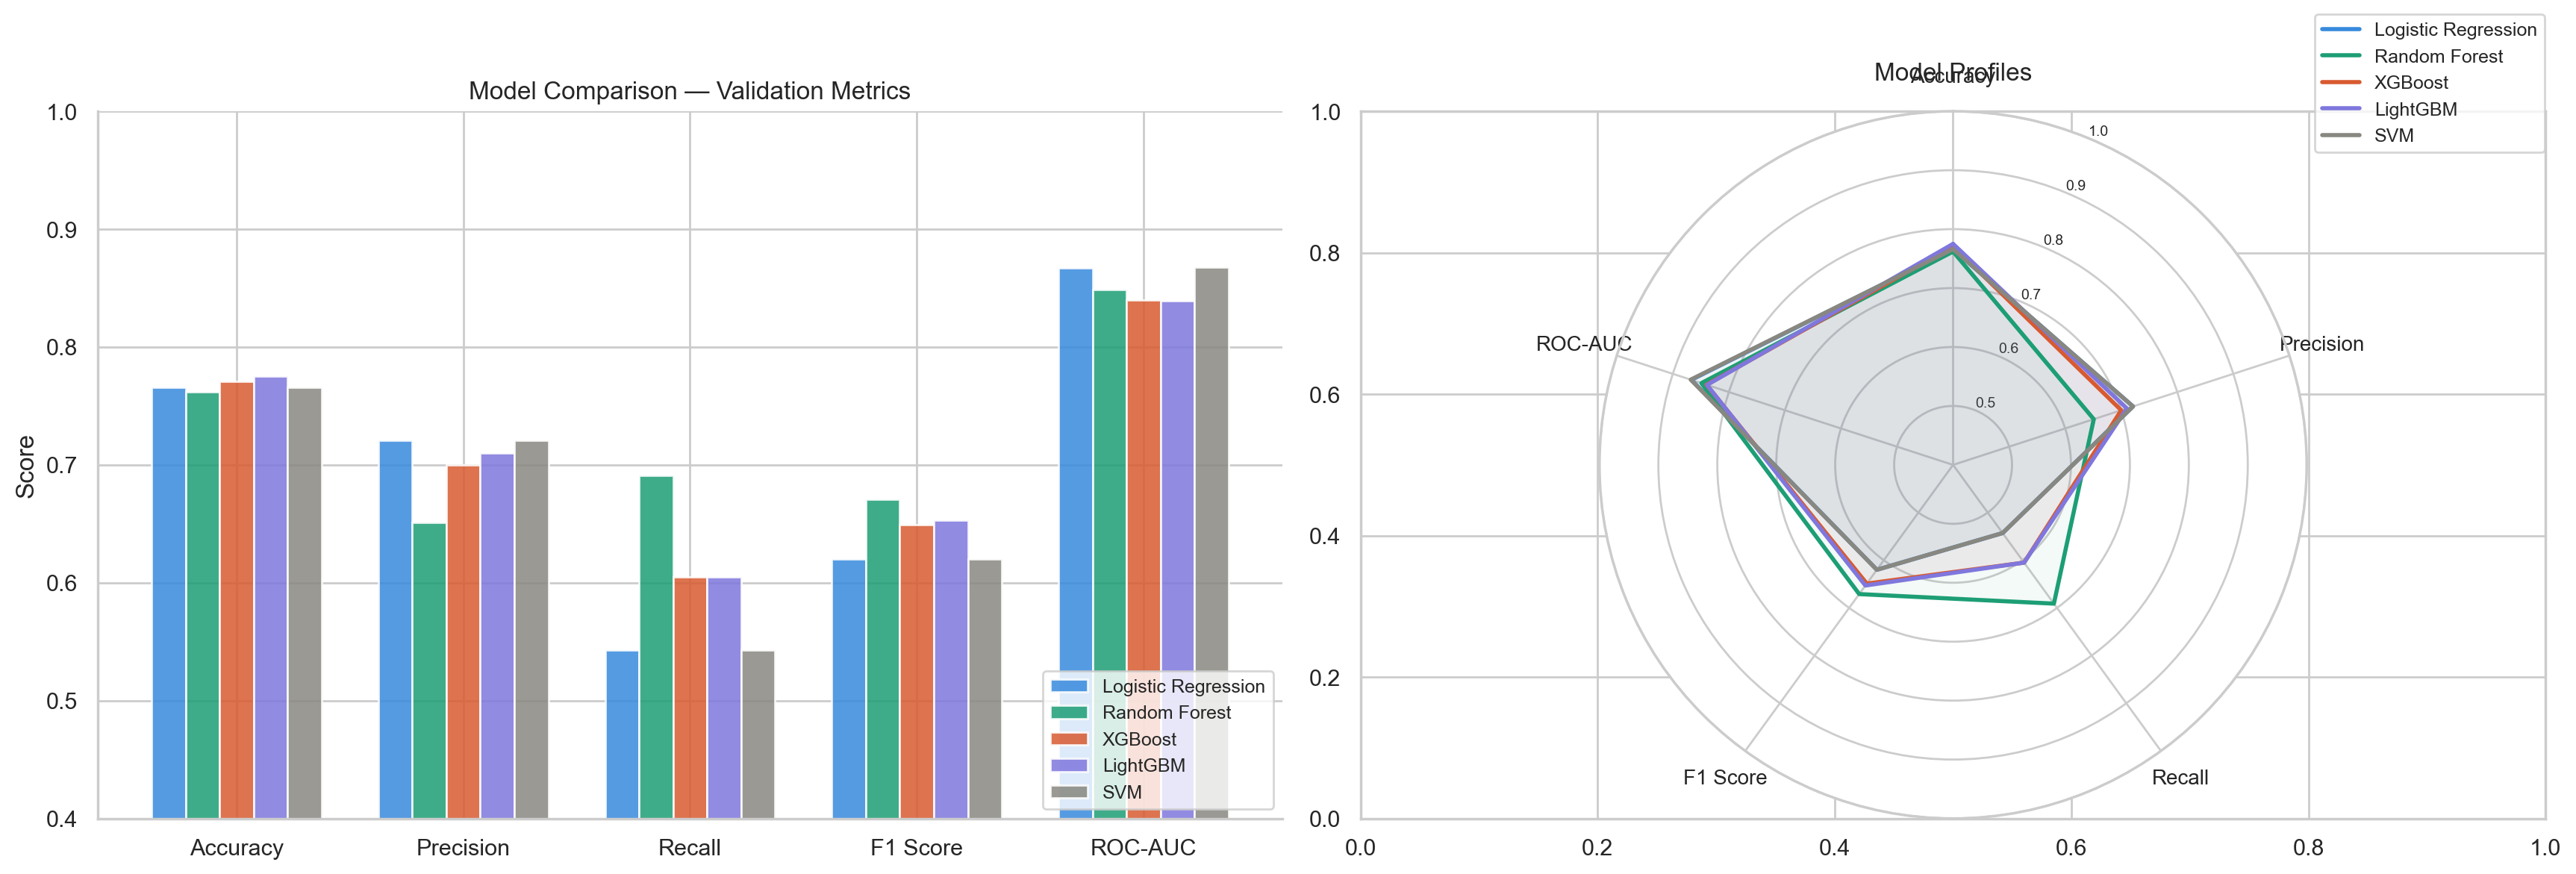

In [192]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

results = {
    'Logistic Regression': [0.766, 0.721, 0.543, 0.620, 0.867],
    'Random Forest':       [0.762, 0.651, 0.691, 0.671, 0.849],
    'XGBoost':             [0.771, 0.700, 0.605, 0.649, 0.840],
    'LightGBM':            [0.775, 0.710, 0.605, 0.653, 0.839],
    'SVM':                 [0.766, 0.721, 0.543, 0.620, 0.868],
}

colors = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#888780']

x = np.arange(len(metrics))
n_models = len(results)
width = 0.15

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Grouped Bar Chart ---
ax = axes[0]
for i, (model, values) in enumerate(results.items()):
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=model, color=colors[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.4, 1.0)
ax.set_title('Model Comparison — Validation Metrics')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylabel('Score')
sns.despine(ax=ax)

# --- Radar Chart ---
ax2 = axes[1]
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

ax2 = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylim(0.4, 1.0)
ax2.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax2.set_yticklabels(['0.5','0.6','0.7','0.8','0.9','1.0'], fontsize=7)

for i, (model, values) in enumerate(results.items()):
    vals = values + values[:1]
    ax2.plot(angles, vals, color=colors[i], linewidth=2, label=model)
    ax2.fill(angles, vals, color=colors[i], alpha=0.05)

ax2.set_title('Model Profiles', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.show()